# Day 3 — Exploratory Data Analysis
**Bluestock MF Analytics Capstone**

15+ charts on NAV, AUM, SIP, investor and portfolio data, read from the
`data/processed/` CSVs produced by `etl_pipeline.py` and `compute_metrics.py`.
Run the scripts first if you haven't. Charts are also saved to `reports/figures/`.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# robust path resolution — works whether the kernel cwd is notebooks/ or project root
ROOT = Path.cwd()
while not (ROOT/"data"/"processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
P   = ROOT/"data"/"processed"
FIG = ROOT/"reports"/"figures"; FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

fund  = pd.read_csv(P/"dim_fund.csv")
nav   = pd.read_csv(P/"fact_nav.csv", parse_dates=["date"])
aum   = pd.read_csv(P/"fact_aum.csv", parse_dates=["date"])
sip   = pd.read_csv(P/"fact_sip_industry.csv")
cat   = pd.read_csv(P/"fact_category_inflow.csv")
fol   = pd.read_csv(P/"fact_folio.csv")
tx    = pd.read_csv(P/"fact_transactions.csv", parse_dates=["transaction_date"])
ph    = pd.read_csv(P/"fact_portfolio.csv")
met   = pd.read_csv(P/"computed_metrics.csv")
score = pd.read_csv(P/"fund_scorecard.csv")
print("loaded", len(fund), "funds,", len(nav), "NAV rows,", len(tx), "transactions")

loaded 40 funds, 46000 NAV rows, 32778 transactions


## 1. NAV growth (rebased to 100) — all 40 schemes
Rebasing makes funds with very different NAV levels comparable on one axis.

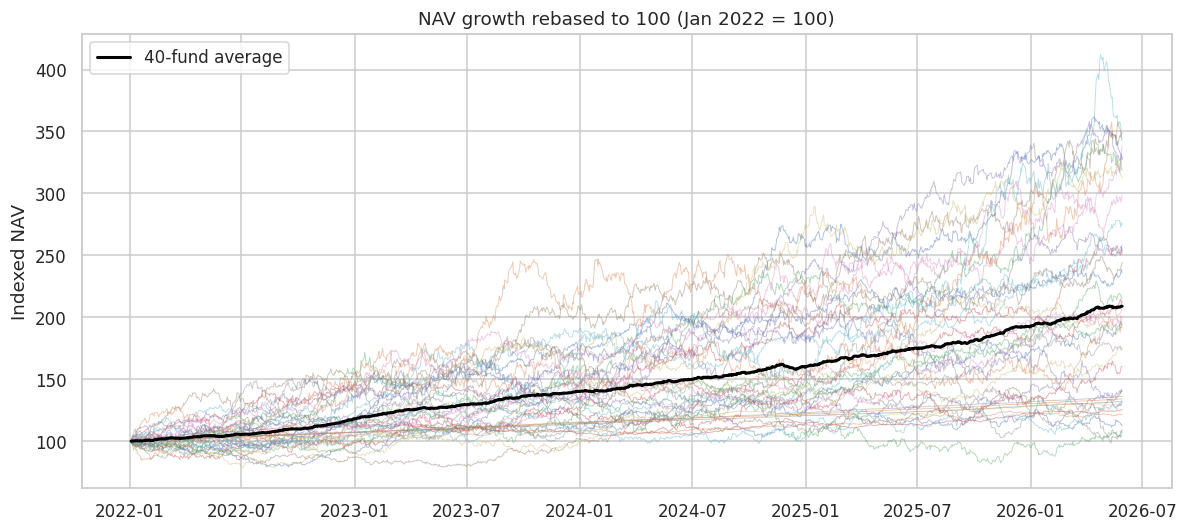

In [2]:
piv = nav.pivot(index="date", columns="amfi_code", values="nav").sort_index()
reb = piv / piv.iloc[0] * 100
plt.figure(figsize=(11,5))
for col in reb.columns: plt.plot(reb.index, reb[col], lw=.6, alpha=.45)
plt.plot(reb.index, reb.mean(axis=1), color="black", lw=2, label="40-fund average")
plt.title("NAV growth rebased to 100 (Jan 2022 = 100)"); plt.ylabel("Indexed NAV")
plt.legend(); plt.tight_layout(); plt.savefig(FIG/"01_nav_trends.png", bbox_inches="tight"); plt.show()

## 2. AUM by fund house (year-end)
SBI leads the industry; the grouped bars show year-on-year growth per AMC.

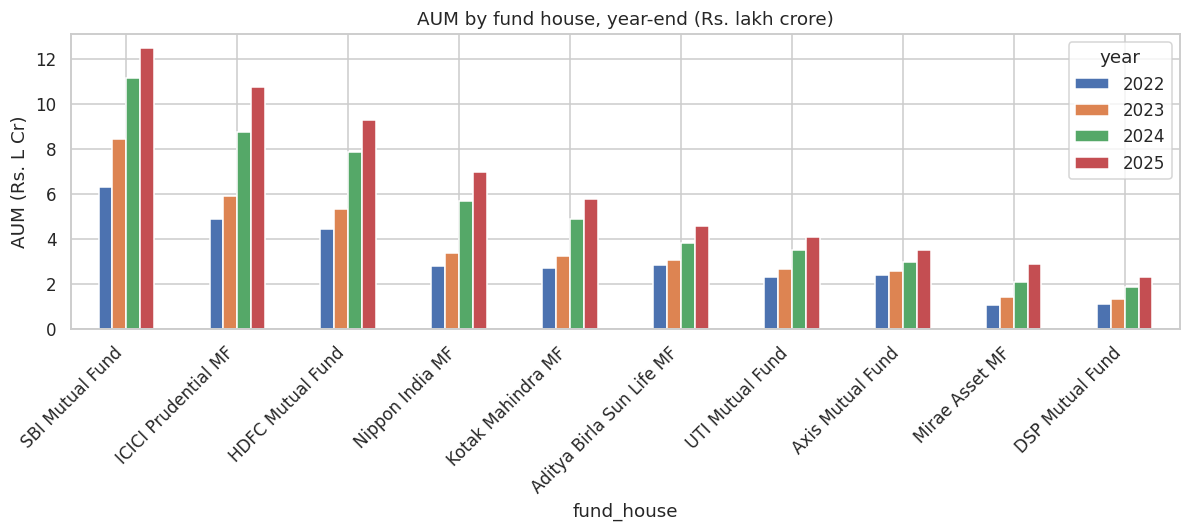

In [3]:
aum["year"] = aum.date.dt.year
latest = aum.sort_values("date").groupby(["fund_house","year"]).tail(1)
pv = latest.pivot(index="fund_house", columns="year", values="aum_lakh_crore").sort_values(2025, ascending=False)
pv.plot(kind="bar", figsize=(11,5))
plt.title("AUM by fund house, year-end (Rs. lakh crore)"); plt.ylabel("AUM (Rs. L Cr)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.savefig(FIG/"02_aum_by_house.png", bbox_inches="tight"); plt.show()

## 3. Monthly SIP inflows + Rs.31,002 Cr milestone (Dec 2025)

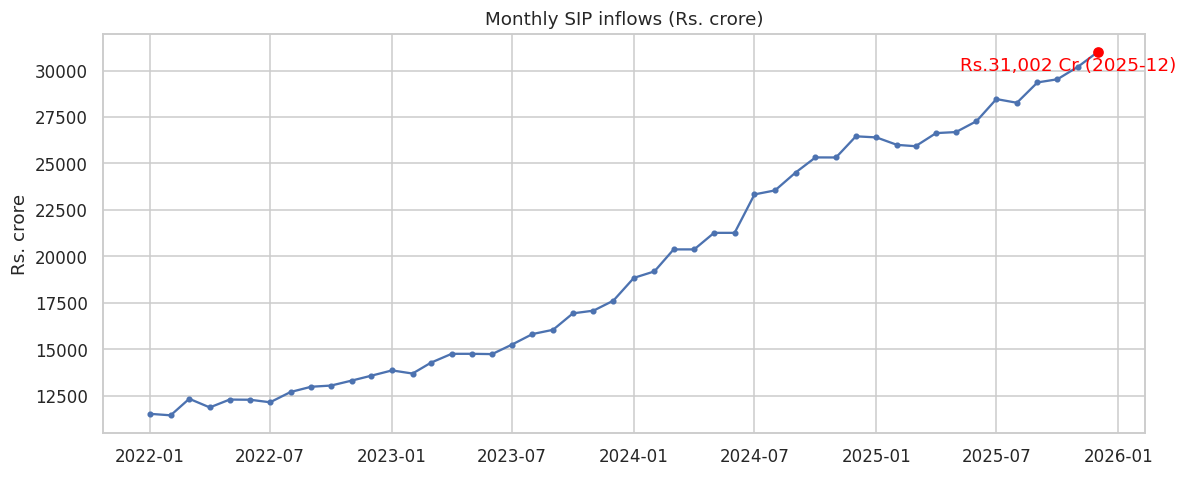

In [4]:
sip["month_dt"] = pd.to_datetime(sip.month)
plt.figure(figsize=(11,4.5))
plt.plot(sip.month_dt, sip.sip_inflow_crore, marker="o", ms=3)
peak = sip.loc[sip.sip_inflow_crore.idxmax()]
plt.scatter(peak.month_dt, peak.sip_inflow_crore, color="red", zorder=5)
plt.annotate(f"Rs.{peak.sip_inflow_crore:,} Cr ({peak.month})", (peak.month_dt, peak.sip_inflow_crore),
             textcoords="offset points", xytext=(-90,-12), color="red")
plt.title("Monthly SIP inflows (Rs. crore)"); plt.ylabel("Rs. crore")
plt.tight_layout(); plt.savefig(FIG/"03_sip_timeline.png", bbox_inches="tight"); plt.show()

## 4. Category net-inflow heatmap (FY24-25)
Liquid funds dwarf every other category — typical of short-term cash parking.

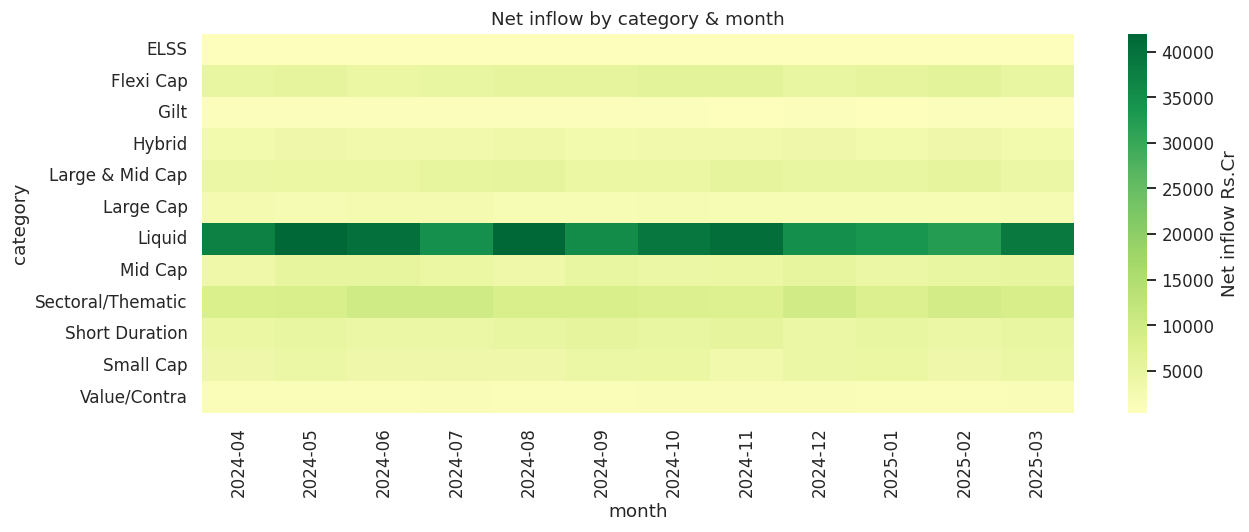

In [5]:
cp = cat.pivot(index="category", columns="month", values="net_inflow_crore")
plt.figure(figsize=(12,5))
sns.heatmap(cp, cmap="RdYlGn", center=0, cbar_kws={"label":"Net inflow Rs.Cr"})
plt.title("Net inflow by category & month"); plt.xticks(rotation=90)
plt.tight_layout(); plt.savefig(FIG/"04_category_heatmap.png", bbox_inches="tight"); plt.show()

## 5. Investor demographics — age mix & SIP size by age

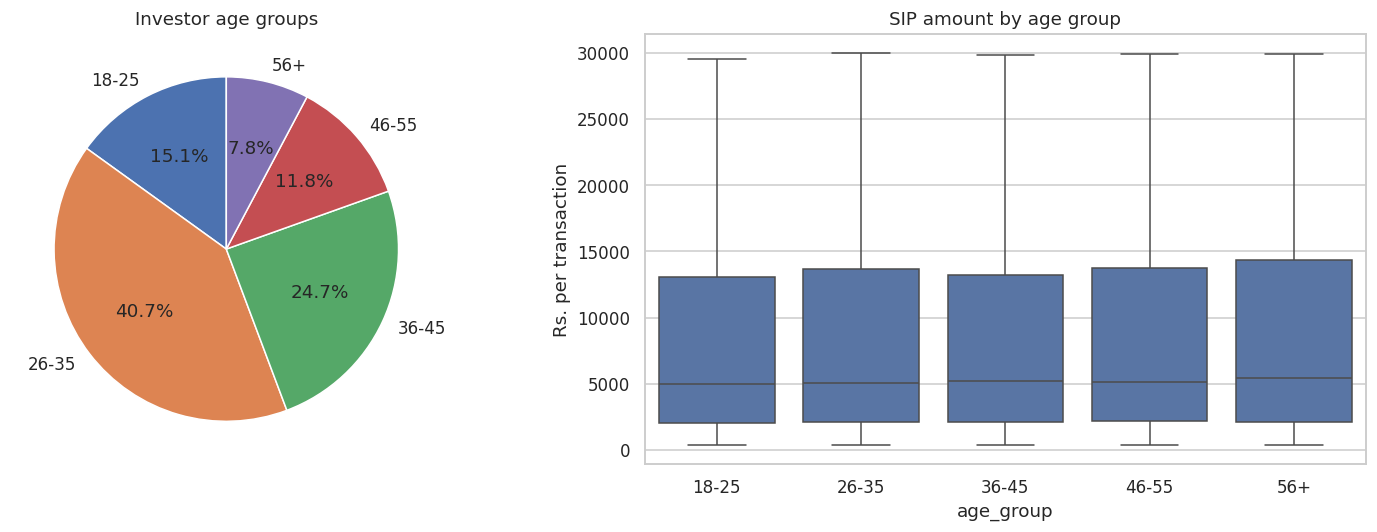

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
ag = tx.drop_duplicates("investor_id").age_group.value_counts().sort_index()
ax[0].pie(ag, labels=ag.index, autopct="%1.1f%%", startangle=90); ax[0].set_title("Investor age groups")
sns.boxplot(data=tx[tx.transaction_type=="SIP"], x="age_group", y="amount_inr",
            order=sorted(tx.age_group.unique()), showfliers=False, ax=ax[1])
ax[1].set_title("SIP amount by age group"); ax[1].set_ylabel("Rs. per transaction")
plt.tight_layout(); plt.savefig(FIG/"05_demographics.png", bbox_inches="tight"); plt.show()

## 6. Geography — SIP value by state & T30 vs B30 split

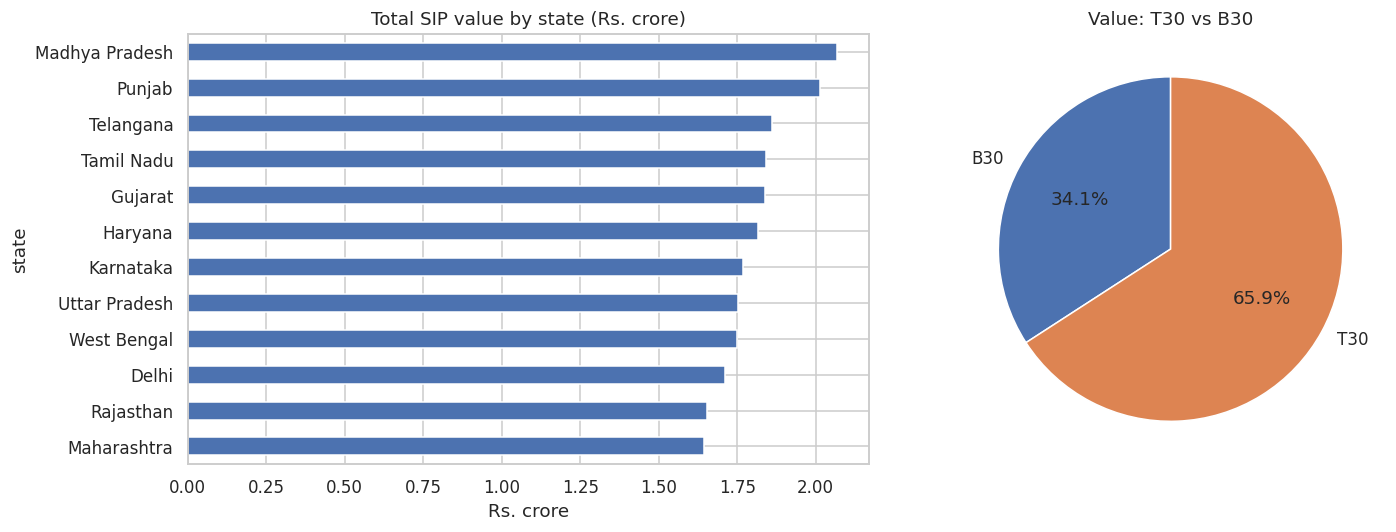

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
st = tx[tx.transaction_type=="SIP"].groupby("state").amount_inr.sum().div(1e7).sort_values()
st.plot(kind="barh", ax=ax[0]); ax[0].set_title("Total SIP value by state (Rs. crore)"); ax[0].set_xlabel("Rs. crore")
tier = tx.groupby("city_tier").amount_inr.sum()
ax[1].pie(tier, labels=tier.index, autopct="%1.1f%%", startangle=90); ax[1].set_title("Value: T30 vs B30")
plt.tight_layout(); plt.savefig(FIG/"06_geography.png", bbox_inches="tight"); plt.show()

## 7. MF folio growth (13.26 -> 26.12 crore)

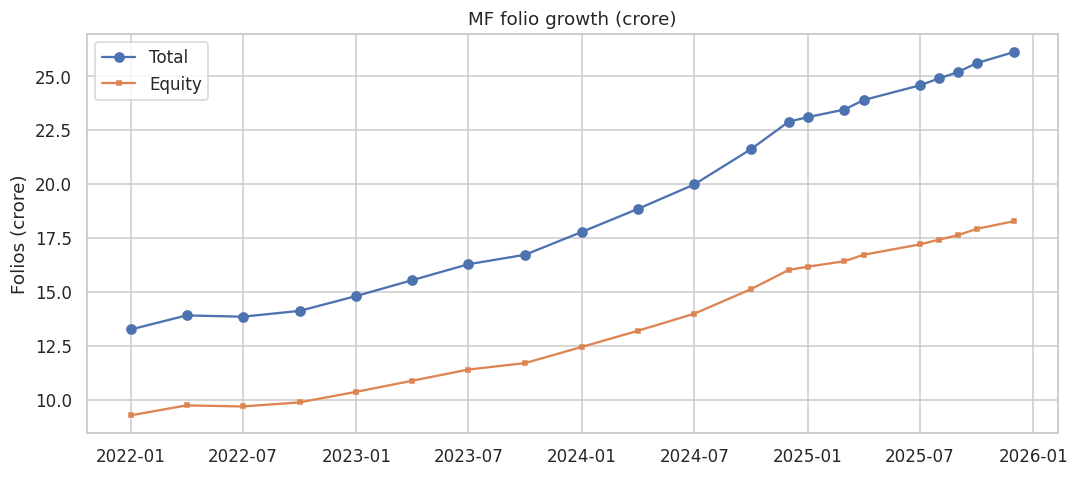

In [8]:
fol["month_dt"] = pd.to_datetime(fol.month)
plt.figure(figsize=(10,4.5))
plt.plot(fol.month_dt, fol.total_folios_crore, marker="o", label="Total")
plt.plot(fol.month_dt, fol.equity_folios_crore, marker="s", ms=3, label="Equity")
plt.title("MF folio growth (crore)"); plt.ylabel("Folios (crore)"); plt.legend()
plt.tight_layout(); plt.savefig(FIG/"07_folio_growth.png", bbox_inches="tight"); plt.show()

## 8. Daily-return correlation — 10 equity funds

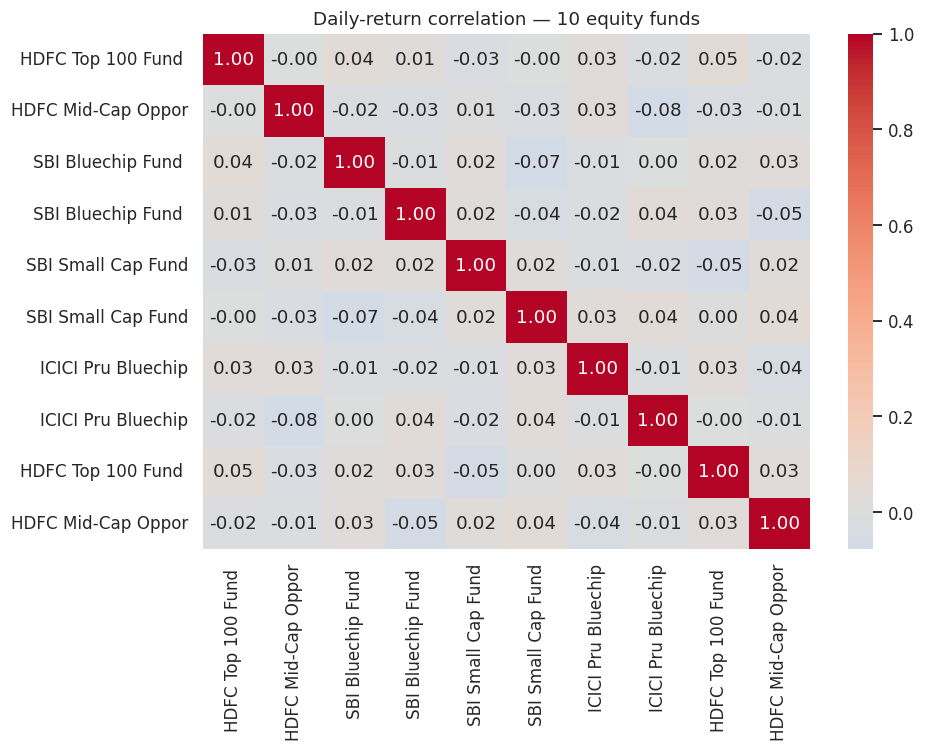

In [9]:
eq = fund[fund.category=="Equity"].amfi_code.head(10).tolist()
rets = nav[nav.amfi_code.isin(eq)].pivot(index="date", columns="amfi_code", values="daily_return")
names = fund.set_index("amfi_code").scheme_name.str[:18]
rets.columns = [names[col] for col in rets.columns]
plt.figure(figsize=(9,7)); sns.heatmap(rets.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Daily-return correlation — 10 equity funds")
plt.tight_layout(); plt.savefig(FIG/"08_return_corr.png", bbox_inches="tight"); plt.show()

## 9. Sector exposure across equity portfolios (value-weighted)

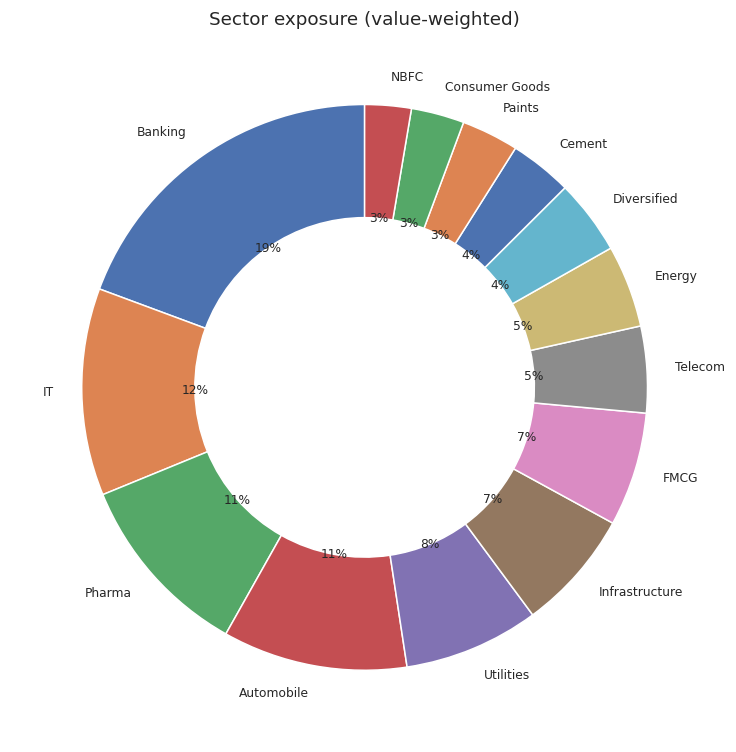

In [10]:
sec = ph.groupby("sector").market_value_cr.sum().sort_values(ascending=False)
plt.figure(figsize=(7,7))
plt.pie(sec, labels=sec.index, autopct="%1.0f%%", startangle=90,
        wedgeprops=dict(width=.4), textprops={"fontsize":8})
plt.title("Sector exposure (value-weighted)")
plt.tight_layout(); plt.savefig(FIG/"09_sector_donut.png", bbox_inches="tight"); plt.show()

## 10. Transaction mix & monthly volume

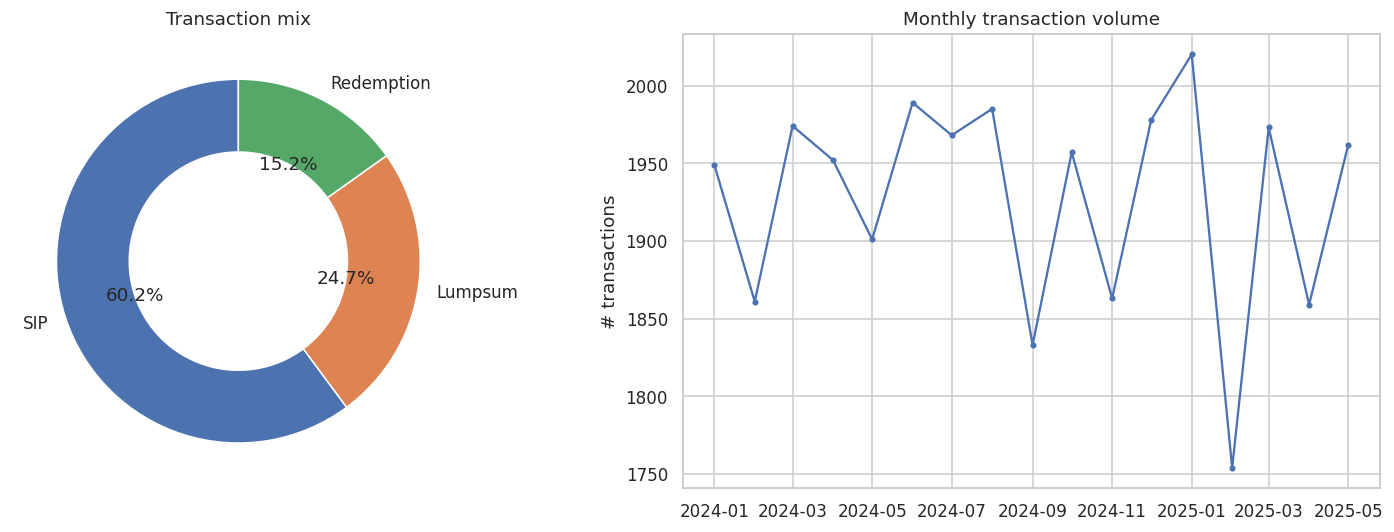

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
mix = tx.transaction_type.value_counts()
ax[0].pie(mix, labels=mix.index, autopct="%1.1f%%", startangle=90, wedgeprops=dict(width=.4))
ax[0].set_title("Transaction mix")
tx["ym"] = tx.transaction_date.dt.to_period("M").dt.to_timestamp()
vol = tx.groupby("ym").size()
ax[1].plot(vol.index, vol.values, marker="o", ms=3); ax[1].set_title("Monthly transaction volume")
ax[1].set_ylabel("# transactions")
plt.tight_layout(); plt.savefig(FIG/"10_tx_mix_volume.png", bbox_inches="tight"); plt.show()

## 11. Risk vs return (bubble size = Sharpe)

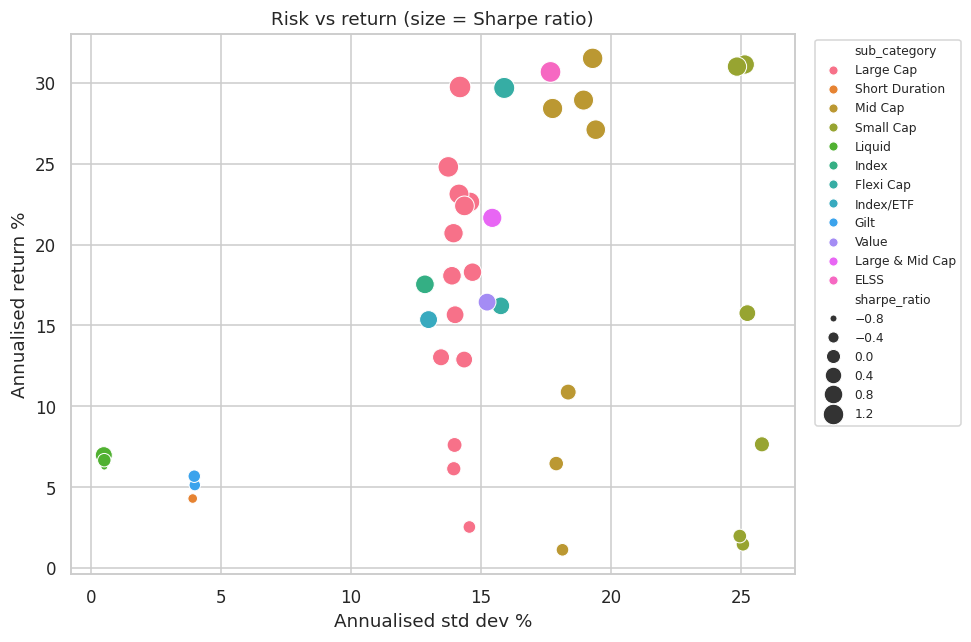

In [12]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=met, x="std_dev_ann_pct", y="annualised_return_pct",
                hue="sub_category", size="sharpe_ratio", sizes=(20,200))
plt.title("Risk vs return (size = Sharpe ratio)"); plt.xlabel("Annualised std dev %")
plt.ylabel("Annualised return %"); plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"11_risk_return.png", bbox_inches="tight"); plt.show()

## 12. Expense ratio by sub-category & avg SIP by income

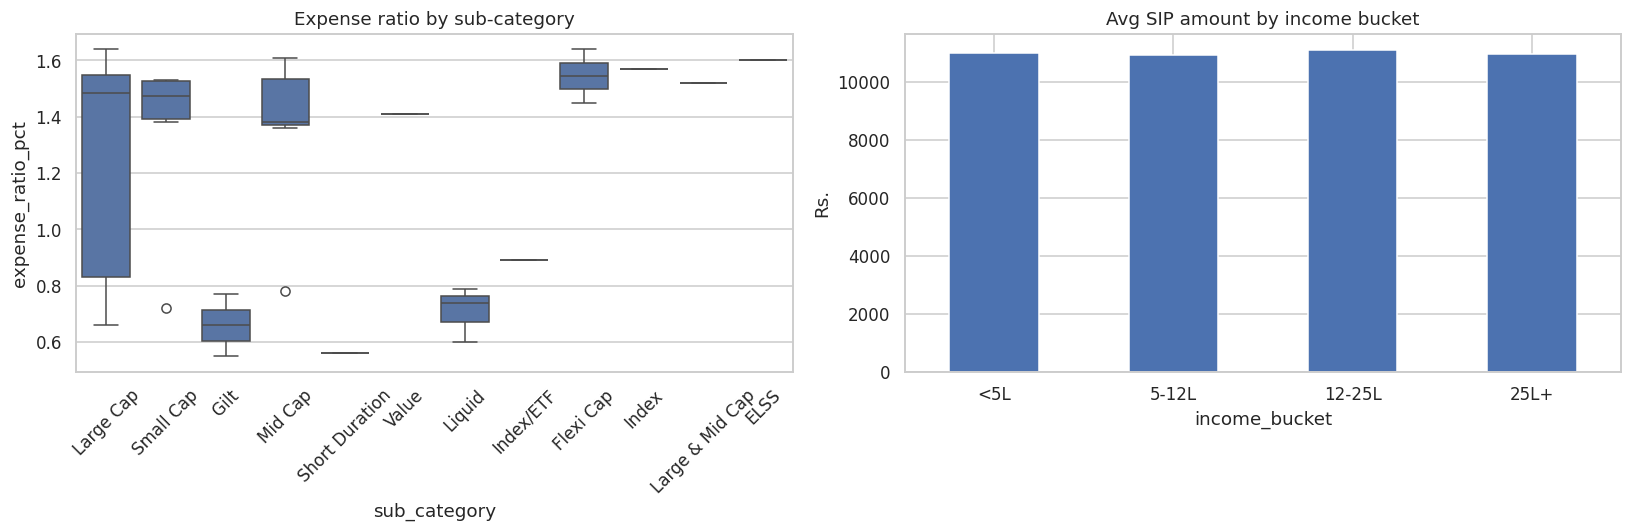

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(data=fund, x="sub_category", y="expense_ratio_pct", ax=ax[0])
ax[0].tick_params(axis="x", rotation=45); ax[0].set_title("Expense ratio by sub-category")
tx["income_bucket"] = pd.cut(tx.annual_income_lakh, [0,5,12,25,1000], labels=["<5L","5-12L","12-25L","25L+"])
inc = tx[tx.transaction_type=="SIP"].groupby("income_bucket", observed=True).amount_inr.mean()
inc.plot(kind="bar", ax=ax[1]); ax[1].set_title("Avg SIP amount by income bucket"); ax[1].set_ylabel("Rs.")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(FIG/"12_expense_income.png", bbox_inches="tight"); plt.show()

## 13. Top 10 funds by composite score

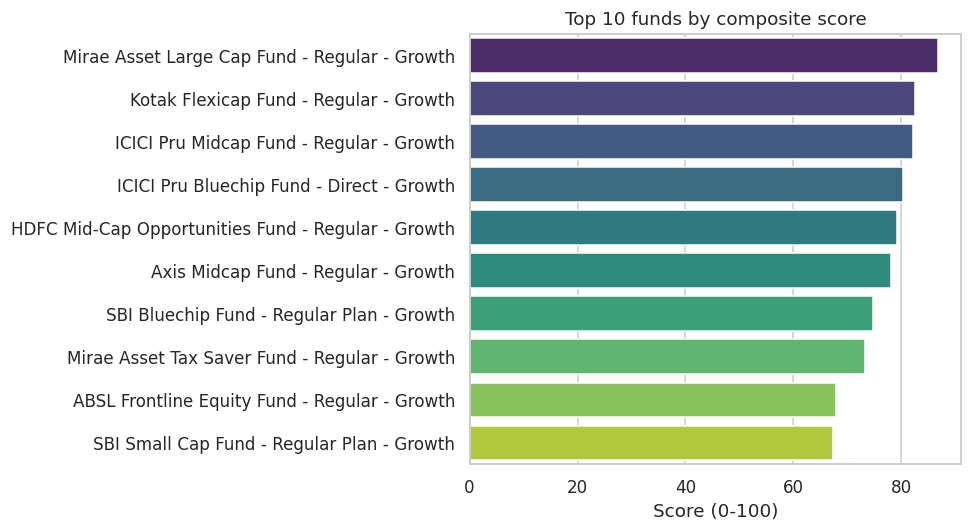

In [14]:
top = score.head(10)
plt.figure(figsize=(9,5))
sns.barplot(data=top, y="scheme_name", x="score", hue="scheme_name", palette="viridis", legend=False)
plt.title("Top 10 funds by composite score"); plt.xlabel("Score (0-100)"); plt.ylabel("")
plt.tight_layout(); plt.savefig(FIG/"13_top_scorecard.png", bbox_inches="tight"); plt.show()

## Key EDA findings

1. **Equity vs debt divergence is stark.** Rebased to 100, equity schemes reach 300–400 by mid-2026 while debt/liquid funds stay near 110–140 — the 40-fund average lands around 210.
2. **SIP inflows hit the Rs.31,002 crore all-time high in Dec 2025**, the headline industry milestone.
3. **Folios more than doubled**, from 13.26 crore (Jan 2022) to 26.12 crore, with equity folios driving most of the growth.
4. **Liquid funds dominate category net inflows**, dwarfing equity categories every month — consistent with short-term corporate cash parking rather than long-term investing.
5. **T30 cities contribute ~65.9% of transaction value vs ~34.1% from B30** — urban concentration persists, though B30 is a meaningful and growing share.
6. **Transaction mix is SIP-led**: ~60.2% SIP, ~24.7% Lumpsum, ~15.2% Redemption — a healthy systematic-investing skew.
7. **Banking is the single largest sector exposure** across the equity portfolios by market value.
8. **Mid-cap funds post the highest raw returns** (Axis Midcap ~35.1% 3yr CAGR) but with larger drawdowns; large-caps offer better risk-adjusted scores.
9. **Best composite-scored fund: Mirae Asset Large Cap (~86.8/100)** — strong Sharpe with a contained ~11% max drawdown.
10. **SIP ticket size rises with both age and income**, but even younger/lower-income cohorts participate heavily, showing broad-based SIP adoption.

*Note: NAV is synthetic (anchored to real AMFI values), so figures illustrate methodology rather than live market truth.*